In [ ]:
!pip install librosa
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install torch torchvision

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import models
import torchvision.transforms as transforms

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/dsl-dataset"

In [ ]:
audio_folder = os.path.join(dataset_path, "wavfiles")
metadata_file = os.path.join(dataset_path, "bird_songs_metadata.csv")

In [ ]:
metadata = pd.read_csv(metadata_file)

metadata.head()

,id,genus,species,subspecies,name,recordist,country,location,latitude,longitude,altitude,sound_type,source_url,license,time,date,remarks,filename
0,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-0.wav
1,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-1.wav
2,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-4.wav
3,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-5.wav
4,557838,Thryomanes,bewickii,NaN,Bewick's Wren,Whitney Neufeld-Kaiser,United States,"Arlington, Snohomish County, Washington",48.0708,-122.1006,100,"adult, sex uncertain, song",//www.xeno-canto.org/557838,//creativecommons.org/licenses/by-nc-sa/4.0/,11:51,2020-03-14,"Recorded with Voice Record Pro on iPhone7, nor...",557838-6.wav


In [ ]:
print(metadata.columns)

Index(['id', 'genus', 'species', 'subspecies', 'name', 'recordist', 'country',
       'location', 'latitude', 'longitude', 'altitude', 'sound_type',
       'source_url', 'license', 'time', 'date', 'remarks', 'filename'],
      dtype='object')


In [ ]:
file_path = os.path.join(audio_folder, metadata.iloc[0]["filename"])

y, sr = librosa.load(file_path, sr=22050)

print("Sample rate:", sr)
print("Audio length:", len(y))

Sample rate: 22050
Audio length: 66150


In [ ]:
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

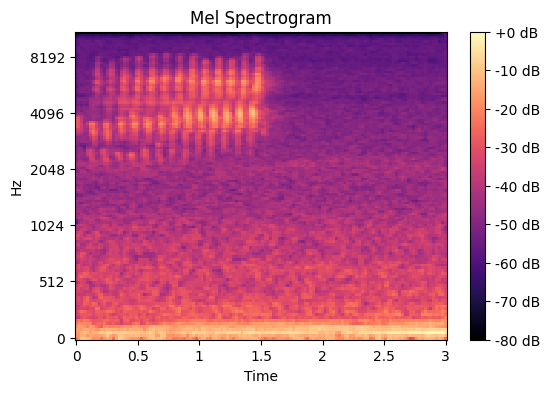

In [ ]:
plt.figure(figsize=(6,4))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()

In [ ]:
spectrogram_folder = "/content/spectrograms"

os.makedirs(spectrogram_folder, exist_ok=True)

In [ ]:
for index, row in metadata.iterrows():

    filename = row["filename"]
    species = row["species"]

    audio_path = os.path.join(audio_folder, filename)

    y, sr = librosa.load(audio_path, sr=22050)

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    species_folder = os.path.join(spectrogram_folder, species)
    os.makedirs(species_folder, exist_ok=True)

    save_path = os.path.join(species_folder, filename.replace(".wav",".png"))

    plt.imsave(save_path, mel_spec_db)

In [ ]:
!mv /content/spectrograms /content/drive/MyDrive/

In [ ]:
!ls /content/drive/MyDrive/spectrograms

bewickii  cardinalis  melodia  migratorius  polyglottos


In [ ]:
spectrogram_folder = "/content/drive/MyDrive/spectrograms"

In [ ]:
from torchvision.datasets import ImageFolder

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

dataset = ImageFolder(spectrogram_folder, transform=transform)

In [ ]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

Remember to switch runtime to GPU before training. Cell below this hasn't been run.

In [ ]:
import torch
import random
seed = 42

torch.manual_seed(seed)        # 👈 PyTorch seed
np.random.seed(seed)           # 👈 NumPy seed
random.seed(seed)              # 👈 Python seed

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [ ]:
train_idx, test_idx = train_test_split(
    list(range(len(dataset))),
    test_size=0.2,
    stratify=dataset.targets,
    random_state=seed
)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
test_dataset = torch.utils.data.Subset(dataset, test_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=2,
    pin_memory=True
)

In [ ]:
model = models.resnet18(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(dataset.classes))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(5):
    model.train()

    for i, (images, labels) in enumerate(train_loader):

        print(f"Loading batch {i}")   # 👈 DEBUG LINE

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 10 == 0:
            print(f"Epoch {epoch}, Batch {i}, Loss: {loss.item():.4f}")

Loading batch 0
Epoch 0, Batch 0, Loss: 1.7112
Loading batch 1
Loading batch 2
Loading batch 3
Loading batch 4
Loading batch 5
Loading batch 6
Loading batch 7
Loading batch 8
Loading batch 9
Loading batch 10
Epoch 0, Batch 10, Loss: 1.1254
Loading batch 11
Loading batch 12
Loading batch 13
Loading batch 14
Loading batch 15
Loading batch 16
Loading batch 17
Loading batch 18
Loading batch 19
Loading batch 20
Epoch 0, Batch 20, Loss: 1.1018
Loading batch 21
Loading batch 22
Loading batch 23
Loading batch 24
Loading batch 25
Loading batch 26
Loading batch 27
Loading batch 28
Loading batch 29
Loading batch 30
Epoch 0, Batch 30, Loss: 0.5545
Loading batch 31
Loading batch 32
Loading batch 33
Loading batch 34
Loading batch 35
Loading batch 36
Loading batch 37
Loading batch 38
Loading batch 39
Loading batch 40
Epoch 0, Batch 40, Loss: 0.5028
Loading batch 41
Loading batch 42
Loading batch 43
Loading batch 44
Loading batch 45
Loading batch 46
Loading batch 47
Loading batch 48
Loading batch 49
L

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 90.4147465437788


In [ ]:
torch.save(model.state_dict(),
           "/content/drive/MyDrive/bird_model.pth")

In [ ]:
import pandas as pd

results = {
    "Epochs": 5,
    "Final Accuracy": 90.41
}

df = pd.DataFrame([results])
df.to_csv("/content/drive/MyDrive/results.csv", index=False)

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[170   1   1   3   4]
 [  2 207   2   2   2]
 [ 34  10 194   6   7]
 [  0   1   1 196   5]
 [  6   7   1   9 214]]
